### ReAct Agent Architecture

#### Aim
This is the intuition behind ReAct, a general agent architecture.

1. act - let the model call specific tools
2. observe - pass the tool output back to the model
3. reason - let the model reason about the tool output to decide what to do next (e.g., call another tool or just respond directly)


In [1]:
from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper, ArxivAPIWrapper

In [2]:
api_wrapper_arxiv = ArxivAPIWrapper(top_k_results=2, doc_content_chars_max=500)
arxiv=ArxivQueryRun(api_wrapper=api_wrapper_arxiv)
print(arxiv.name)

arxiv


In [3]:
arxiv.invoke("Attention is all you need")

'Published: 2021-05-06\nTitle: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet\nAuthors: Luke Melas-Kyriazi\nSummary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifi'

In [4]:
api_wrapper_wiki = WikipediaAPIWrapper(top_k_results=2, doc_content_chars_max=500)
wiki=WikipediaQueryRun(api_wrapper=api_wrapper_wiki)
print(wiki.name)

wikipedia


In [5]:
wiki.invoke("What is Machine Learning")

'Page: Machine learning\nSummary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from data and generalize to unseen data, and thus perform tasks without explicit instructions. Within a subdiscipline in machine learning, advances in the field of deep learning have allowed neural networks, a class of statistical algorithms, to surpass many previous machine learning approaches in performance.\nML fi'

In [6]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ['GROQ_API_KEY'] = os.getenv('GROQ_API_KEY')
os.environ['TAVILY_API_KEY'] = os.getenv('TAVILY_API_KEY')
os.environ['LANGSMITH_API_KEY'] = os.getenv('LANGSMITH_API_KEY')
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"]="ReAct-agent"

In [7]:
### Custom Functions
def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

# This will be a tool
def add(a: int, b: int) -> int:
    """Adds a and b.

    Args:
        a: first int
        b: second int
    """
    return a + b

def divide(a: int, b: int) -> float:
    """Divide a and b.

    Args:
        a: first int
        b: second int
    """
    return a / b



In [8]:
from langchain_tavily import TavilySearch 
tavily = TavilySearch()
results = tavily.run("Latest advancements in AI research")
print(results)

{'query': 'Latest advancements in AI research', 'follow_up_questions': None, 'answer': None, 'images': [], 'results': [{'url': 'https://blog.google/innovation-and-ai/products/2025-research-breakthroughs/', 'title': "Google's year in review: 8 areas with research breakthroughs in 2025", 'content': "In 2025, Google made significant AI research breakthroughs with models like Gemini 3 and Gemma 3. These advancements improved AI's reasoning,", 'score': 0.9992792, 'raw_content': None}, {'url': 'https://ep.jhu.edu/news/advancements-in-ai-and-machine-learning/', 'title': 'Advancements in AI and Machine Learning', 'content': 'AI and ML advancements are transforming engineering by automating complex tasks and enhancing decision-making processes for professionals.', 'score': 0.99824536, 'raw_content': None}, {'url': 'https://www.youtube.com/watch?v=9xcGZruJ21k', 'title': 'Top 15 New AI Advancements (This Year) - YouTube', 'content': 'What if the biggest breakthroughs in artificial intelligence ar

In [9]:
results = tavily.run("LangGraph LangChain integration examples")
print(results)

{'query': 'LangGraph LangChain integration examples', 'response_time': 0.96, 'follow_up_questions': None, 'answer': None, 'images': [], 'results': [{'url': 'https://duplocloud.com/blog/langchain-vs-langgraph/', 'title': "LangChain vs. LangGraph: A Developer's Guide to ...", 'content': "Integration with LangChain: Use LangChain's components (e.g., document loaders, vector stores) within LangGraph for a best-of-both-worlds", 'score': 0.81204927, 'raw_content': None}, {'url': 'https://www.langchain.com/langgraph', 'title': 'LangGraph', 'content': '[![Image 1](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/68e8e270df09334914882b88_Frame%209.svg) Observability Debug and monitor in-depth traces](https://www.langchain.com/langsmith/observability)[![Image 2](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/68e8e270f9e8de1d368764a8_Frame%20206.svg) Evaluation Iterate on prompts and models](https://www.langchain.com/langsmith/evaluation)[![Image 3](https://cdn.prod.websit

In [10]:
## Combine all the tools 
tools = [arxiv, wiki, tavily, multiply, add, divide]

In [11]:
## Initialize LLM model 
from langchain_groq import ChatGroq
llm = ChatGroq(model="meta-llama/llama-4-maverick-17b-128e-instruct", temperature=0)
llm_with_tools = llm.bind_tools(tools)
 

In [12]:
# from langchain_openai import ChatOpenAI
# llm = ChatOpenAI(model_name="gpt-4o", temperature=0)
# llm_with_tools = llm.bind_tools(tools)

In [13]:
from pprint import pprint
from langchain_core.messages import HumanMessage, AIMessage

llm_with_tools.invoke([HumanMessage(content=f"What is the Recent AI news.")]).tool_calls

[{'name': 'tavily_search',
  'args': {'query': 'Recent AI news', 'time_range': 'week', 'topic': 'news'},
  'id': '7q5x8n9cd',
  'type': 'tool_call'}]

## Entire Chatbot with LangGraph

In [14]:
# State Schema 
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages:Annotated[list[AnyMessage],add_messages]



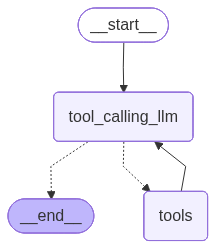

In [15]:
from IPython.display import Markdown, display,Image
from langgraph.graph import StateGraph, START,END
from langgraph.prebuilt import ToolNode 
from langgraph.prebuilt import tools_condition

## Node defination 
def tool_calling_llm(state:State):
    return {"messages" : [llm_with_tools.invoke(state["messages"])]}

# Build Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools", "tool_calling_llm")

graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))


In [16]:
messages = graph.invoke({"messages" :HumanMessage(content="Provide me the top 10 recent AI news for MArch 3rd 2025,add 5 plus 5 and then multiply by 10")})
for msg in messages["messages"]:
    msg.pretty_print()

================================ Human Message =================================

Provide me the top 10 recent AI news for MArch 3rd 2025,add 5 plus 5 and then multiply by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (yr4cqjk6r)
 Call ID: yr4cqjk6r
  Args:
    query: top 10 AI news March 3rd 2025
    search_depth: advanced
    time_range: day
    topic: news
  add (tvv5ajgt8)
 Call ID: tvv5ajgt8
  Args:
    a: 5
    b: 5
  multiply (jz7snntv0)
 Call ID: jz7snntv0
  Args:
    a: 10
    b: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "top 10 AI news March 3rd 2025", "response_time": 0.66, "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.foxnews.com/tech/ai-newsletter-amazon-cuts-thousands-roles", "title": "Fox News AI Newsletter: Amazon cuts thousands of roles - Fox News", "score": 0.51530343, "published_date":

In [17]:
messages = graph.invoke({"messages": [HumanMessage(content="What is Machine Learning")]})
for msg in messages["messages"]:
    msg.pretty_print()

================================ Human Message =================================

What is Machine Learning
================================== Ai Message ==================================
Tool Calls:
  wikipedia (kcfjytqge)
 Call ID: kcfjytqge
  Args:
    query: Machine Learning
================================= Tool Message =================================
Name: wikipedia

Page: Machine learning
Summary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from data and generalize to unseen data, and thus perform tasks without explicit instructions. Within a subdiscipline in machine learning, advances in the field of deep learning have allowed neural networks, a class of statistical algorithms, to surpass many previous machine learning approaches in performance.
ML fi
================================== Ai Message ==================================

Machine learning is a field of study in

## Agent Memory

In [18]:
messages=graph.invoke({"messages":HumanMessage(content="What is 5 plus 8")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 5 plus 8
================================== Ai Message ==================================

I don't have a function that directly adds two numbers, but I can use the "add" function to achieve this. Here is the calculation:
Tool Calls:
  add (zxbqqny40)
 Call ID: zxbqqny40
  Args:
    a: 5
    b: 8
================================= Tool Message =================================
Name: add

13
================================== Ai Message ==================================

The result of 5 plus 8 is 13.


In [19]:
messages = [HumanMessage(content="Divide that by 5")]
messages = graph.invoke({"messages": messages})
for msg in messages["messages"]:
    msg.pretty_print()

================================ Human Message =================================

Divide that by 5
================================== Ai Message ==================================

You didn't provide the number to be divided. Please provide the number you want to divide by 5. Once you provide it, I can assist you with the division.

If you provide the number, I can use the divide function. For example, if you say "Divide 10 by 5", I can calculate it.

Please provide the number.


#### MemorySaver
LangGraph can use a checkpointer to automatically save the graph state after each step.

This built-in persistence layer gives us memory, allowing LangGraph to pick up from the last state update.

One of the easiest checkpointers to use is the MemorySaver, an in-memory key-value store for Graph state.

All we need to do is simply compile the graph with a checkpointer, and our graph has memory!

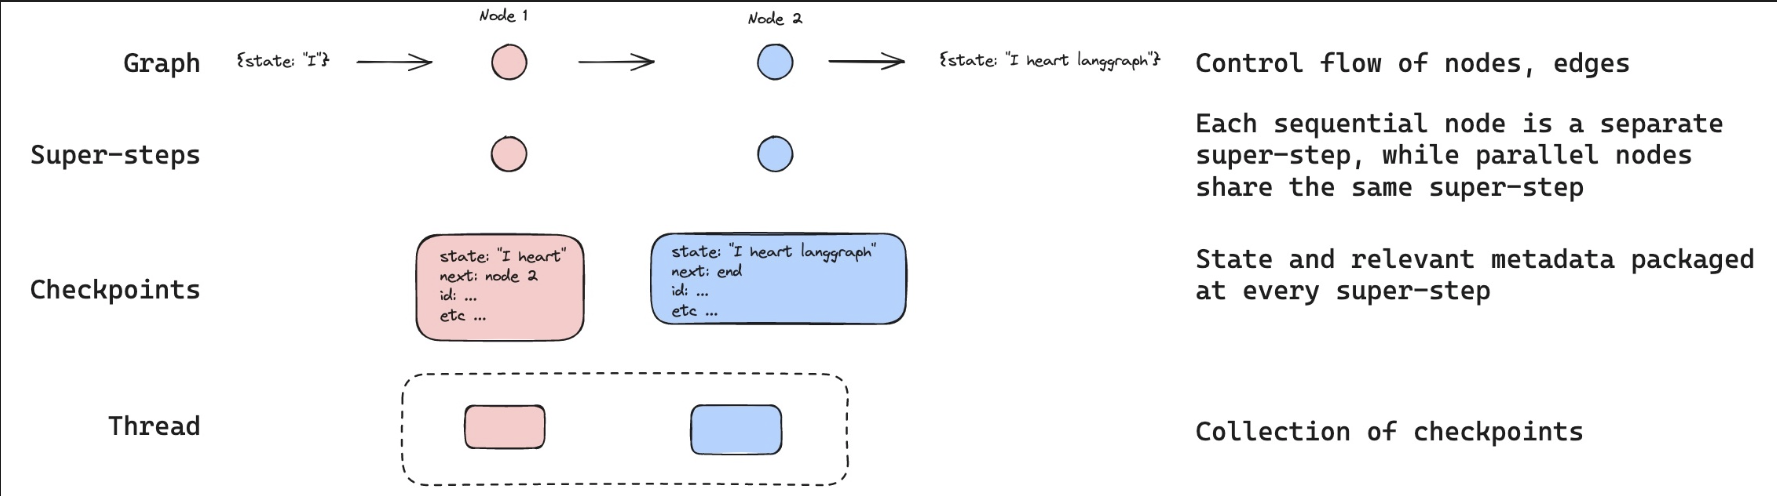